In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import requests
from sklearn.model_selection import train_test_split
from openai import OpenAI
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [3]:
# Load data
data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_1115/1113152288.py:2: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,NaN,NaN,NaN,Y,"51,514.62","7,552.54"
1,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"25,370.86","3,469.55"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,NaN,NaN,NaN,N,"23,876.78","6,180.33"
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"43,319.05","12,588.93"
4,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"40,266.23","10,355.99"


In [4]:
for col in data.columns:
    print(col, data[col].dtype)

Hospital Service Area object
Hospital County object
Operating Certificate Number float64
Permanent Facility Id float64
Facility Name object
Age Group object
Zip Code - 3 digits object
Gender object
Race object
Ethnicity object
Length of Stay object
Type of Admission object
Patient Disposition object
Discharge Year int64
CCSR Diagnosis Code object
CCSR Diagnosis Description object
CCSR Procedure Code object
CCSR Procedure Description object
APR DRG Code int64
APR DRG Description object
APR MDC Code int64
APR MDC Description object
APR Severity of Illness Code int64
APR Severity of Illness Description object
APR Risk of Mortality object
APR Medical Surgical Description object
Payment Typology 1 object
Payment Typology 2 object
Payment Typology 3 object
Birth Weight object
Emergency Department Indicator object
Total Charges object
Total Costs object


In [5]:
# Remove commas and convert to numeric
for col in ["Length of Stay", "Birth Weight", "Total Charges", "Total Costs"]:
    data[col] = pd.to_numeric(data[col].str.replace(',', '', regex=False), errors='coerce')


In [6]:
for col in data.columns:
    print(col, data[col].dtype)

Hospital Service Area object
Hospital County object
Operating Certificate Number float64
Permanent Facility Id float64
Facility Name object
Age Group object
Zip Code - 3 digits object
Gender object
Race object
Ethnicity object
Length of Stay float64
Type of Admission object
Patient Disposition object
Discharge Year int64
CCSR Diagnosis Code object
CCSR Diagnosis Description object
CCSR Procedure Code object
CCSR Procedure Description object
APR DRG Code int64
APR DRG Description object
APR MDC Code int64
APR MDC Description object
APR Severity of Illness Code int64
APR Severity of Illness Description object
APR Risk of Mortality object
APR Medical Surgical Description object
Payment Typology 1 object
Payment Typology 2 object
Payment Typology 3 object
Birth Weight float64
Emergency Department Indicator object
Total Charges float64
Total Costs float64


In [7]:
# Handle missing numeric data
for col in data.columns:
    if data[col].dtype != "object":
        data[col] = data[col].fillna(data[col].median())

In [8]:
# Identify categorical columns 
categorical_columns = []
for col in data.columns:
    if data[col].dtype == "object":
        categorical_columns.append(col)

# Encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)


In [9]:
# Preprocess data
X = data_encoded.drop(columns=['Total Costs'])
y = data_encoded['Total Costs']

In [10]:
prev_columns = X.columns
new_columns = []
for col in X.columns:
    if "[" in col or "]" in col:
        new_columns.append(col.replace('[', '').replace("]", ""))
    elif "<" in col:
        new_columns.append(col.replace("<", "less than"))
    else:
        new_columns.append(col)

In [11]:
X.columns = new_columns

In [12]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Train the model
model = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 3894.10
MSE: 278250241.61
R²: 0.88


In [15]:
# Explain model predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

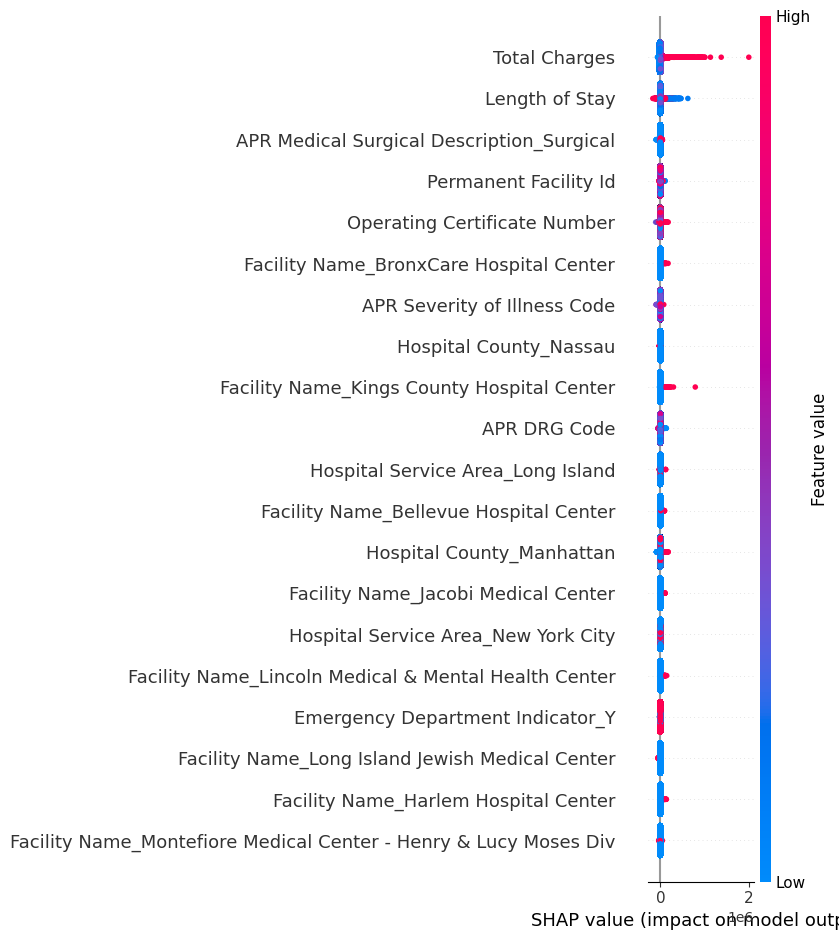

In [16]:
# Visualize feature importance
shap.summary_plot(shap_values, X_test)

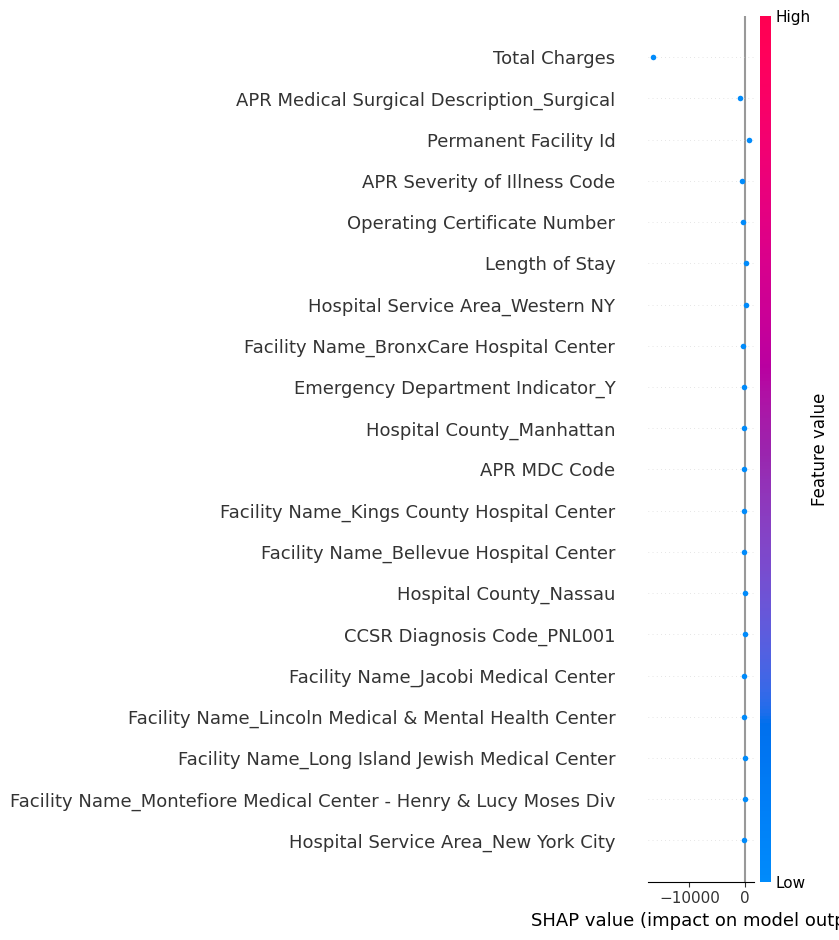

In [17]:
shap_values = explainer(X_test.iloc[0:1])
shap.summary_plot(shap_values, X_test.iloc[0:1])

In [18]:
shap_values

.values =
array([[-3.6670660e+02,  7.5831201e+02,  3.2596985e+02, ...,
        -3.5924505e-02,  1.8017679e+01, -1.8022337e+02]], dtype=float32)

.base_values =
array([23430.934], dtype=float32)

.data =
array([[1401014.0, 207.0, 3.0, ..., False, False, True]], dtype=object)

In [19]:
shap_values.values[0]

array([-3.6670660e+02,  7.5831201e+02,  3.2596985e+02, ...,
       -3.5924505e-02,  1.8017679e+01, -1.8022337e+02], dtype=float32)

In [20]:
# Calculate mean absolute SHAP values
shap_mean = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap_value': shap_values.values.mean(axis=0)
})

shap_mean_nonzero = shap_mean[(shap_mean['mean_shap_value'] > 10) | (shap_mean['mean_shap_value'] < -10)]

# Sort features by importance
shap_mean_nonzero = shap_mean_nonzero.sort_values(by='mean_shap_value', ascending=False)

print(shap_mean_nonzero)

                                        feature  mean_shap_value
1                         Permanent Facility Id       758.312012
2                                Length of Stay       325.969849
15             Hospital Service Area_Western NY       309.945068
43                       Hospital County_Nassau       110.948952
758                  CCSR Diagnosis Code_PNL001        90.858215
...                                         ...              ...
81      Facility Name_BronxCare Hospital Center      -202.374817
0                  Operating Certificate Number      -366.706604
6                  APR Severity of Illness Code      -383.013428
2324  APR Medical Surgical Description_Surgical      -813.675842
8                                 Total Charges    -16616.289062

[85 rows x 2 columns]


In [21]:
def patient_info(i, shap_mean_nonzero):
    info = ""
    for col in X_test.columns:
        try:
            info += f"{col}: value = {X_test.iloc[i][col]}, shap value = {shap_mean_nonzero[shap_mean_nonzero['feature']==col]['mean_shap_value'].tolist()[0]}\n"
        except:
            pass
    return info

In [22]:
# Agentic AI using OpenAI API to suggest interventions
prompt = f"""
You are a healthcare cost-optimization agent. Based on these top cost drivers:
{patient_info(0, shap_mean_nonzero)}
Suggest actionable interventions hospitals can apply to reduce costs without compromising care quality.
"""

In [23]:
print(prompt)


You are a healthcare cost-optimization agent. Based on these top cost drivers:
Operating Certificate Number: value = 1401014.0, shap value = -366.70660400390625
Permanent Facility Id: value = 207.0, shap value = 758.31201171875
Length of Stay: value = 3.0, shap value = 325.9698486328125
APR DRG Code: value = 55, shap value = -46.903526306152344
APR MDC Code: value = 1, shap value = -128.31436157226562
APR Severity of Illness Code: value = 1, shap value = -383.013427734375
Total Charges: value = 11499.47, shap value = -16616.2890625
Hospital Service Area_Long Island: value = False, shap value = 47.650081634521484
Hospital Service Area_New York City: value = False, shap value = -83.47077178955078
Hospital Service Area_Western NY: value = True, shap value = 309.945068359375
Hospital County_Bronx: value = False, shap value = 26.864633560180664
Hospital County_Manhattan: value = False, shap value = -143.4241180419922
Hospital County_Nassau: value = False, shap value = 110.9489517211914
Hos

In [27]:
pip install langchain

  Using cached PyYAML-6.0.2-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.7/633.7 kB 8.9 MB/s eta 0:00:00
Using cached PyYAML-6.0.2-cp39-cp39-macosx_11_0_arm64.whl (172 kB)
  Attempting uninstall: packaging━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/14 [SQLAlchemy]
    Found existing installation: packaging 25.0━━━━━━━━━━━━━━━  2/14 [SQLAlchemy]
    Uninstalling packaging-25.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/14 [SQLAlchemy]
      Successfully uninstalled packaging-25.0━━━━━━━━━━━━━━━━━  2/14 [SQLAlchemy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [langchain]14 [langchain]core]
Note: you may need to restart the kernel to use updated packages.


In [31]:
from langchain.chat_models import ChatOpenAI
from langchain.schema import HumanMessage


llm = ChatOpenAI(model_name="microsoft/phi-4-reasoning-plus:free", 
                temperature=0.7, 
                base_url="https://openrouter.ai/api/v1",
                api_key="OR_API_KEY",
                )
                 
response = llm([HumanMessage(content=prompt)])
print(response.content)

/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_1115/3127083741.py:5: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name="microsoft/phi-4-reasoning-plus:free",
/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_1115/3127083741.py:11: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm([HumanMessage(content=prompt)])


We are Phi with role "healthcare cost-optimization agent", with provided information: "Based on these top cost drivers: ...". It lists top cost drivers with values and shap values. We are to "suggest actionable interventions hospitals can apply to reduce costs without compromising care quality." We are provided a list of features and their shap values. They are presumably predictions or contributions from a machine learning algorithm such as SHAP values for cost predictions in healthcare. The cost drivers are likely to be features that influence cost. A list of cost drivers: Operating Certificate Number is a cost driver, with negative shap value. Permanent Facility Id is a cost driver with positive shap value. Length of Stay is cost driver with positive shap value. APR DRG Code is a cost driver with negative shap value. APR MDC Code is negative. APR Severity of Illness Code is negative. Total Charges is huge negative shap value. Then hospital service areas: Long Island is false (so not